In [73]:
import torch 
import matplotlib.pyplot as plt 
import torch.nn.functional as F
import re

In [74]:
#data loading 
Batch = 300 
context_size = 10
emb_dim = 300 
hidden_dim = 256 
def load_data (file_path):

    with open(file_path,"r") as F:
        data = F.read()
        return data 
def tokenize (text):
    return re.findall(r"\w+|[^\w\s]|\s",text)

dictionary = sorted(set(tokenize(load_data("ptbdataset\ptb.test.txt"))))
word_to_index = {word:i for i,word in enumerate(dictionary)  }
index_to_word = {i:word for i ,word in enumerate(dictionary)}

encode = lambda l: [word_to_index[i] for i in re.findall(r"\w+|[^\w\s]|\s",l)]

decode = lambda l: [index_to_word[i] for i in l]


def Softmax (logit ):
    logit = logit- logit.max(dim=1 ,keepdim=True).values
    exp = logit.exp()
    prob = exp/exp.sum(dim=1,keepdim=True )
    return prob



# def crossEntropy (softmax,y):
    
    

<>:14: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:14: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_10900\1570025520.py:14: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  dictionary = sorted(set(tokenize(load_data("ptbdataset\ptb.test.txt"))))


In [75]:
encoded = encode(load_data("ptbdataset\ptb.test.txt"))

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_10900\4083066583.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  encoded = encode(load_data("ptbdataset\ptb.test.txt"))


In [76]:

X = []
Y = []

for i in range(len(encoded) - context_size):
    X.append(encoded[i:i+context_size])
    Y.append(encoded[i+context_size])

In [77]:
X = torch.tensor(X)
Y = torch.tensor(Y)
emb = torch.randn(len(dictionary),emb_dim ,requires_grad=True )
w1 = torch.randn( context_size*emb_dim,hidden_dim,requires_grad=True)
w2 = torch.randn(hidden_dim,len(dictionary),requires_grad=True)



In [78]:
flaten  = emb[x].view(Batch,-1)
flaten.shape,w1.shape
# l1 = torch.tanh(flaten@w1)

(torch.Size([300, 3000]), torch.Size([3000, 256]))

In [ ]:
lossplot = [ ]
for i in range(5000):
    #weight 
    ix = torch.randint(0, X.shape[0], (Batch,))

    x = X[ix]
    y = Y[ix]
    lr = 0.01
    flaten  = emb[x].view(Batch,-1)
    l1 = torch.tanh(flaten@w1)
    logit = l1@w2
    softmax  = Softmax(logit)

    loss = F.cross_entropy(logit,y)

    loss.backward()
    with torch.no_grad():
        w1 -= lr * w1.grad
        w2-= lr * w2.grad
        emb-=lr*emb.grad

        # w1 /= w1.norm(dim=1, keepdim=True)
        # w2 /= w2.norm(dim=1, keepdim=True)
        # w1 /= w1.norm(dim=1, keepdim=True)
        w1.grad = None
        w2.grad = None
        emb.grad = None
    lossplot.append(loss.item())
    if i%10 ==0:
        print(f"step{i}, Loss:{loss.item():.4f}")
    if i%100 == 0 :

        generate()
    if i%1000:
       lr /=10



step0, Loss:64.6971
reachoffertrumprecallseekssuccessorjailedpromptpitprofessorcraigrobertsintojournalsoybeanimprovementsongbecauseagencieschasestoptastesummitmotiveannouncedpartlyseemsautomaticquitprobeshakingrhetoricpartnershipquietdassaultwednesdayproperlypacedecisionsdoornovelsknoweducationacidspielvogelsoybeanscouncilmwarrenreboundeveninflowslanguagechoosessteamcompaqfuturenewtimemartinfailurereceivinglotusbreakingexpresspointedterrorismlastsrepresentativesreducingarrivenoriegagokansasproceedingsdeputyconnangelessuccessfullynegotiatingparticipatingbeginbushcomplaintsdoesferrantiarewindowsshielderaplummetedconvertbrokerageexamplesintegrationcandidatesofficerslongerelementending
step10, Loss:59.6810
step20, Loss:55.8598
step30, Loss:52.6127
step40, Loss:48.4155
step50, Loss:42.6783
step60, Loss:39.4156
step70, Loss:33.6085
step80, Loss:38.3843
step90, Loss:35.8936
step100, Loss:33.5343
technique mode softnessmercurymullinsprofitsuitors'goldbergappreciationempiredeclaredcreditorsnarr

In [ ]:
flaten  = emb[x].view(Batch,-1)
# l1 = torch.tanh(flaten@w1)
flaten.shape,w1.shape

(torch.Size([300, 2700]), torch.Size([900, 256]))

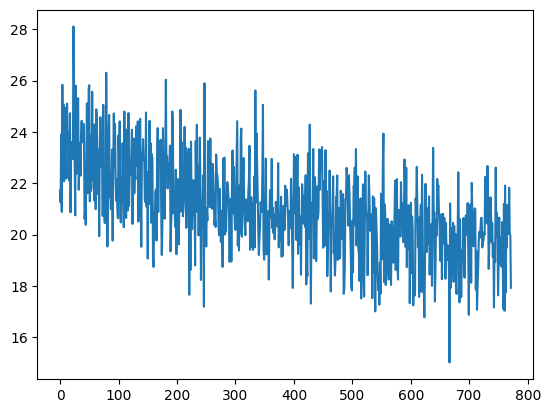

In [ ]:
plt.plot(lossplot)

In [ ]:
"".join(decode(softmax.argmax(dim=1).numpy()))

'complainedcomplainedsacramentoalcohol incheddisksstuff battledeceptivefashionsecuritiesexpiresswingsbethlehemcomplainedcopiescontainer sacramentosufficienthurdlemobilereallyfollowtreatynarrowed reportersassumptionlegislationannouncerindicateinvestmentunprecedentedsisuluauthoritieseatswingscomplainedsabotageseizeddeceptivetimdubbedshoesshipsfeaturing deceptivegainsleoneliminatingoccasion integritytreatytroubledlegislationtimextraordinary attemptsaspectsmobilejoins plight beatencoveringreallysurgerycrazydeceptiveswings machinesovietstryingcontacttakescalculationsbarrettstuffcropcostmobile eliminatingerodedlegislation takeseliminatingbeatenarticles52journalistcomplained sovietsstuffservingattemptsreceptionobligationsspecifypredictiontedstuffbeatenwelcomemontgomerylegislationtroubledfeaturingcostexpiresmixolympiatroubledcraig legislationupheld expirestakeover interesting inchedfarmpersistentswingsplightcarlrejectsupportingeliminatingreferring troubledeatcomfortable  interestinglegislation

In [ ]:
context_tokens = encode(" happy to have")[-context_size:]
X_tensor = torch.tensor([context_tokens])
flaten = emb[X_tensor].view(1,-1)
flaten.shape ,w1.shape
# l1 = torch.tanh(flaten @ w1)

(torch.Size([1, 1800]), torch.Size([3000, 256]))

In [ ]:
def generate(seed="happy to see and here from you today have you gone back "):
    generated = []

    seed_text = seed
    context_tokens = encode(seed_text)[-context_size:]

    for i in range(100):
        X_tensor = torch.tensor([context_tokens])
        flaten = emb[X_tensor].view(1,-1)
       
        l1 = torch.tanh(flaten @ w1)
        logit = l1 @ w2

        temperature = 0.8
        softmax_temp = Softmax(logit / temperature)
        predict = torch.multinomial(softmax_temp, 1).item()

        generated.append(predict)
        context_tokens = context_tokens[1:] + [predict]

    generated_text = "".join([t if t.strip() else " " for t in decode(generated)])
    print(generated_text)


In [ ]:
import torch
import torch.nn.functional as F
import re
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Data Loading & Tokenization
# -------------------------------

def load_data(file_path):
    with open(file_path, "r") as f:
        return f.read()

# Tokenize words, spaces, punctuation
def tokenize(text):
    return re.findall(r"\w+|[^\w\s]|\s", text)

# Load dataset
data = load_data("ptbdataset/ptb.test.txt")
tokens = tokenize(data)

# Build dictionary
vocab = sorted(set(tokens))
word_to_index = {w: i for i, w in enumerate(vocab)}
index_to_word = {i: w for i, w in enumerate(vocab)}

def encode(seq):
    return [word_to_index[t] for t in tokenize(seq)]

def decode(seq):
    return [index_to_word[i] for i in seq]

print(f"Vocabulary size: {len(vocab)} tokens")

# -------------------------------
# 2️⃣ Prepare Training Data
# -------------------------------
context_size = 9
X, Y = [], []
encoded = [word_to_index[t] for t in tokens]

for i in range(len(encoded) - context_size):
    X.append(encoded[i:i+context_size])
    Y.append(encoded[i+context_size])

X = torch.tensor(X)
Y = torch.tensor(Y)

print(f"Training samples: {X.shape[0]}")

# -------------------------------
# 3️⃣ Model Initialization
# -------------------------------

embed_dim = 30
hidden_dim = 256
vocab_size = len(vocab)

# Embeddings + weights
emb = torch.randn(vocab_size, embed_dim, requires_grad=True) 
w1 = torch.randn(context_size * embed_dim, hidden_dim, requires_grad=True)
w2 = torch.randn(hidden_dim, vocab_size, requires_grad=True)
# -------------------------------
# 4️⃣ Training Loop
# -------------------------------
Batch = 128
lr = 0.01
epochs = 50000
loss_history = []

for step in range(epochs):
    # Random batch
    ix = torch.randint(0, X.shape[0], (Batch,))
    x_batch = X[ix]
    y_batch = Y[ix]

    # Forward
    x_emb = emb[x_batch].view(Batch, -1)     # Flatten embeddings
    h = torch.tanh(x_emb @ w1)              # Hidden
    logits = h @ w2                          # Output logits

    # Loss
    loss = F.cross_entropy(logits, y_batch)
    loss.backward()

    # Gradient update + safe weight normalization
    with torch.no_grad():
        w1.data -= lr * w1.grad
        w2.data -= lr * w2.grad
        emb.data -= lr * emb.grad

        # Optional: normalize
        emb.data /= emb.data.norm(dim=1, keepdim=True)
        w1.data /= w1.data.norm(dim=0, keepdim=True)
        w2.data /= w2.data.norm(dim=0, keepdim=True)

        # Zero gradients
        w1.grad.zero_()
        w2.grad.zero_()
        emb.grad.zero_()

    loss_history.append(loss.item())

    # Print and generate text periodically
    if step % 50 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

        # Generate 50 tokens
        context = encode("happy to see")[-context_size:]
        generated = context.copy()
        for _ in range(50):
            x_ctx = torch.tensor([context])
            x_emb_gen = emb[x_ctx].view(1, -1)
            h_gen = torch.tanh(x_emb_gen @ w1)
            logits_gen = h_gen @ w2
            # Temperature sampling
            temperature = 0.8
            probs = F.softmax(logits_gen / temperature, dim=1)
            next_token = torch.multinomial(probs, 1).item()
            generated.append(next_token)
            context = context[1:] + [next_token]

        print("Generated:", "".join([t if t.strip() else " " for t in decode(generated)]))
        print("-" * 80)

# -------------------------------
# 5️⃣ Plot Loss
# -------------------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Steps")
plt.ylabel("Cross-Entropy Loss")
plt.show()

Vocabulary size: 5886 tokens
Training samples: 179026
Step 0, Loss: 55.1185


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x150 and 270x256)